# LiH: Data Efficiency & Feature Importance

1. **Data efficiency curves**: How many training samples does each model need?
2. **Feature importance**: Which features does the RF rely on most?

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from qiskit.quantum_info import Pauli
from qiskit_ibm_runtime.fake_provider import FakeJakartaV2

print('All imports OK')

All imports OK


## 1. Load Data and Build Features

In [2]:
ideal_data = np.load('lih_ideal_data.npy')
noisy_data = np.load('lih_noisy_data.npy')

with open('lih_meta.json') as f:
    meta = json.load(f)

PAULI_LABELS = meta['pauli_labels']
N_QUBITS = meta['n_qubits']
N_2Q = meta['n_2q_gates']
N_SX = meta['n_sx_gates']

backend = FakeJakartaV2()
props = backend.properties()
qubit_props = {}
for q in range(N_QUBITS):
    qubit_props[q] = {
        'T1': props.qubit_property(q, 'T1')[0] * 1e6,
        'T2': props.qubit_property(q, 'T2')[0] * 1e6,
        'readout_error': props.qubit_property(q, 'readout_error')[0],
    }

SYMPLECTIC = {label: np.concatenate([Pauli(label).x.astype(int), Pauli(label).z.astype(int)])
              for label in PAULI_LABELS}
ALL_OBS = list(range(1, len(PAULI_LABELS)))

def qubit_noise_features(symp):
    feats = []
    for q in range(N_QUBITS):
        active = float(symp[q] == 1 or symp[q + N_QUBITS] == 1)
        feats.extend([
            qubit_props[q]['T1'] * active,
            qubit_props[q]['T2'] * active,
            qubit_props[q]['readout_error'] * active,
        ])
    return feats

def build_features(noisy_subset, ideal_subset, obs_indices):
    rows_X, rows_y = [], []
    for obs_idx in obs_indices:
        label = PAULI_LABELS[obs_idx]
        symp = SYMPLECTIC[label]
        noise_feats = qubit_noise_features(symp)
        for i in range(len(noisy_subset)):
            rows_X.append([noisy_subset[i, obs_idx], *symp,
                           N_2Q, N_SX, *noise_feats])
            rows_y.append(ideal_subset[i, obs_idx])
    return np.array(rows_X, dtype=np.float32), np.array(rows_y, dtype=np.float32)

ideal_test = ideal_data[1800:]
noisy_test = noisy_data[1800:]
X_test, y_test = build_features(noisy_test, ideal_test, ALL_OBS)
baseline_mae = mean_absolute_error(y_test, X_test[:, 0])

print(f'Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features')
print(f'Baseline (unmitigated) MAE: {baseline_mae:.4f}')

Test set: 12200 samples, 33 features
Baseline (unmitigated) MAE: 0.0406


## 2. Data Efficiency Curves

Proper train/val/test split:
- Training data split 80/20 into train and validation
- Validation used for early stopping
- Test set evaluated only once at the end

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Linear(hidden, 1))
    def forward(self, x): return self.net(x)

def train_mlp(X_tr, y_tr, X_te, y_te, n_epochs=300, patience=25):
    # 80/20 split for train/validation
    n_val = max(int(0.2 * len(X_tr)), 1)
    idx = np.random.RandomState(42).permutation(len(X_tr))
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    
    X_train_split = X_tr[train_idx]
    y_train_split = y_tr[train_idx]
    X_val = X_tr[val_idx]
    y_val = y_tr[val_idx]
    
    scaler = StandardScaler()
    Xs_tr = scaler.fit_transform(X_train_split)
    Xs_val = scaler.transform(X_val)
    Xs_te = scaler.transform(X_te)

    Xt = torch.tensor(Xs_tr, dtype=torch.float32)
    yt = torch.tensor(y_train_split, dtype=torch.float32).unsqueeze(1)
    Xv = torch.tensor(Xs_val, dtype=torch.float32)
    Xte = torch.tensor(Xs_te, dtype=torch.float32)

    model = MLP(X_tr.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = nn.HuberLoss()

    best_val_mae, best_state, no_imp = float('inf'), None, 0
    for epoch in range(n_epochs):
        model.train()
        opt.zero_grad(); crit(model(Xt), yt).backward(); opt.step()
        
        # Early stopping on VALIDATION set (not test)
        model.eval()
        with torch.no_grad():
            val_mae = mean_absolute_error(y_val, model(Xv).numpy().ravel())
        if val_mae < best_val_mae - 1e-6:
            best_val_mae = val_mae
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= patience: break
    
    # Evaluate on test set ONCE with best model
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_mae = mean_absolute_error(y_te, model(Xte).numpy().ravel())
    return test_mae

train_sizes = [50, 100, 200, 400, 800, 1200, 1800]
rf_maes, mlp_maes = [], []

for n in train_sizes:
    X_tr, y_tr = build_features(noisy_data[:n], ideal_data[:n], ALL_OBS)

    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_mae = mean_absolute_error(y_test, rf.predict(X_test))
    rf_maes.append(rf_mae)

    mlp_mae = train_mlp(X_tr, y_tr, X_test, y_test)
    mlp_maes.append(mlp_mae)

    print(f'  n={n:>5}: RF={rf_mae:.4f}, MLP={mlp_mae:.4f}')

print('Done.')

  n=   50: RF=0.0147, MLP=0.0160
  n=  100: RF=0.0141, MLP=0.0140
  n=  200: RF=0.0138, MLP=0.0147
  n=  400: RF=0.0136, MLP=0.0149
  n=  800: RF=0.0135, MLP=0.0133
  n= 1200: RF=0.0136, MLP=0.0133
  n= 1800: RF=0.0135, MLP=0.0146
Done.


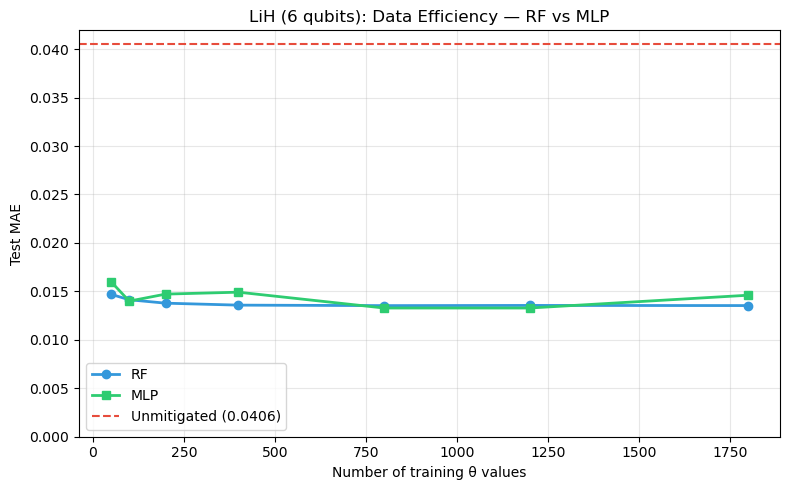

Saved: lih_data_efficiency.png


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(train_sizes, rf_maes, 'o-', color='#3498db', linewidth=2,
        markersize=6, label='RF')
ax.plot(train_sizes, mlp_maes, 's-', color='#2ecc71', linewidth=2,
        markersize=6, label='MLP')
ax.axhline(baseline_mae, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Unmitigated ({baseline_mae:.4f})')

ax.set_xlabel('Number of training \u03b8 values')
ax.set_ylabel('Test MAE')
ax.set_title('LiH (6 qubits): Data Efficiency \u2014 RF vs MLP')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('lih_data_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lih_data_efficiency.png')

## 3. Feature Importance

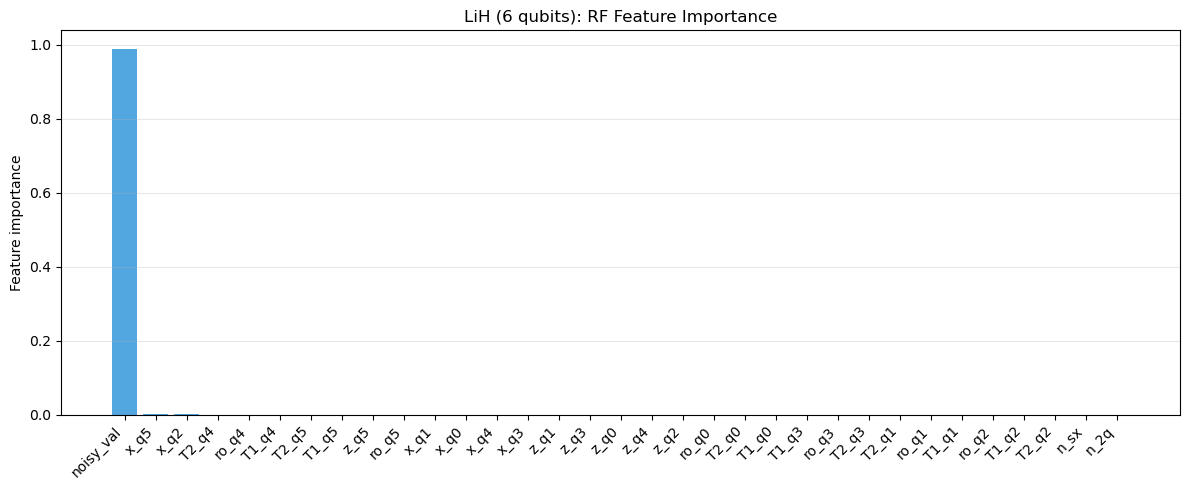


Feature ranking:
  1. noisy_val    0.9899
  2. x_q5         0.0022
  3. x_q2         0.0022
  4. T2_q4        0.0007
  5. ro_q4        0.0006
  6. T1_q4        0.0006
  7. T2_q5        0.0003
  8. T1_q5        0.0003
  9. z_q5         0.0003
  10. ro_q5        0.0003
  11. x_q1         0.0003
  12. x_q0         0.0003
  13. x_q4         0.0002
  14. x_q3         0.0002
  15. z_q1         0.0001
  16. z_q3         0.0001
  17. z_q0         0.0001
  18. z_q4         0.0001
  19. z_q2         0.0001
  20. ro_q0        0.0001
  21. T2_q0        0.0001
  22. T1_q0        0.0001
  23. T1_q3        0.0001
  24. ro_q3        0.0001
  25. T2_q3        0.0001
  26. T2_q1        0.0001
  27. ro_q1        0.0001
  28. T1_q1        0.0001
  29. ro_q2        0.0001
  30. T1_q2        0.0001
  31. T2_q2        0.0001
  32. n_sx         0.0000
  33. n_2q         0.0000

Saved: lih_feature_importance.png


In [5]:
X_full, y_full = build_features(noisy_data[:1800], ideal_data[:1800], ALL_OBS)
rf_full = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_full.fit(X_full, y_full)

feature_names = (
    ['noisy_val'] +
    [f'x_q{i}' for i in range(N_QUBITS)] +
    [f'z_q{i}' for i in range(N_QUBITS)] +
    ['n_2q', 'n_sx'] +
    [f'{p}_q{i}' for i in range(N_QUBITS) for p in ['T1', 'T2', 'ro']]
)

importances = rf_full.feature_importances_
idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(importances)), importances[idx], color='#3498db', alpha=0.85)
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([feature_names[i] for i in idx], rotation=45, ha='right')
ax.set_ylabel('Feature importance')
ax.set_title('LiH (6 qubits): RF Feature Importance')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('lih_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFeature ranking:')
for rank, i in enumerate(idx):
    print(f'  {rank+1}. {feature_names[i]:<12} {importances[i]:.4f}')

print('\nSaved: lih_feature_importance.png')